#  Data Augmentation y Transfer Learning en Imágenes

**Dataset:** CIFAR-10 (10 clases, 60 000 imagenes 32x32 RGB) TensorFlow / Keras  

**Modelos comparados:**

A. Base CNN desde cerosin augmentation

B. Augmentation Misma CNN + Data Augmentation (rotacion, flip, zoom, desplazamiento)

C. Transfer Learning MobileNetV2 preentrenado (ImageNet) + fine-tuning

Para todos se aplico el mismo dataset, mismo split, misma arquitectura de cabeza, solo varia la tecnica aplicada.

---

## 0. Importaciones y configuracion

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)
print("Configuracion lista.")

TensorFlow: 2.20.0
Configuracion lista.


## 1. Preparacion del datasetCIFAR-10

**CIFAR-10** contiene 60 000 imagenes RGB (32x32 px) en 10 clases:  
avion, auto, pajaro, gato, ciervo, perro, rana, caballo, barco, camion.

**Pasos de preprocesamiento:**
- Normalizacion: pixeles [0, 255] → [0, 1]
- Division: 80% entrenamiento / 10% validacion / 10% test
- Para Transfer Learning: redimensionado de 32x32 → 96x96 (minimo MobileNetV2)

In [3]:
# Cargar CIFAR-10 (descarga automatica ~170 MB)
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

CLASES = ["avion","auto","pajaro","gato","ciervo",
          "perro","rana","caballo","barco","camion"]
N_CLASES = 10

# Normalizar pixeles a [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test       = x_test.astype("float32")       / 255.0

# Separar 10% del conjunto de entrenamiento para validacion
val_size = int(0.1 * len(x_train_full))
x_val,   y_val   = x_train_full[:val_size],  y_train_full[:val_size]
x_train, y_train = x_train_full[val_size:],  y_train_full[val_size:]

print(f"Entrenamiento : {x_train.shape}")
print(f"Validacion    : {x_val.shape}")
print(f"Test          : {x_test.shape}")

# Distribucion de clases en entrenamiento
unicas, conteos = np.unique(y_train, return_counts=True)
print("\nDistribucion de clases (entrenamiento):")
for cls, cnt in zip(unicas, conteos):
    print(f"  {CLASES[cls]:<10}: {cnt}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Entrenamiento : (45000, 32, 32, 3)
Validacion    : (5000, 32, 32, 3)
Test          : (10000, 32, 32, 3)

Distribucion de clases (entrenamiento):
  avion     : 4495
  auto      : 4540
  pajaro    : 4481
  gato      : 4514
  ciervo    : 4481
  perro     : 4512
  rana      : 4481
  caballo   : 4514
  barco     : 4480
  camion    : 4502


/tmp/ipykernel_12555/3000431745.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASES[int(label)], fontsize=9)


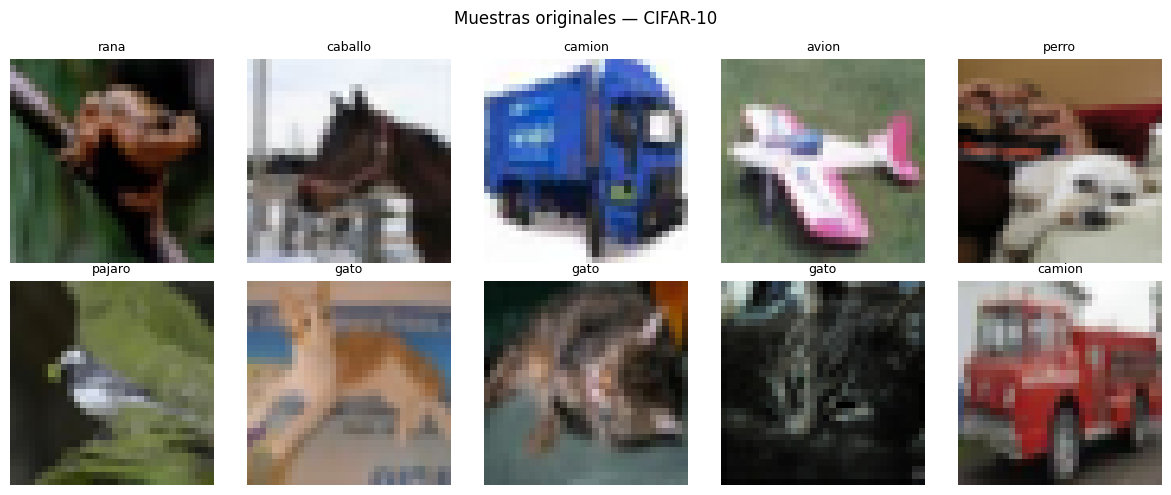

In [4]:
# Visualizar muestras del dataset original
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, label in zip(axes.flat, x_train[:10], y_train[:10]):
    ax.imshow(img)
    ax.set_title(CLASES[int(label)], fontsize=9)
    ax.axis("off")
plt.suptitle("Muestras originales — CIFAR-10", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Data Augmentation

Es una tecnica que genera variantes artificiales de las imagenes de entrenamiento aplicando transformaciones aleatorias (rotacion, volteo, zoom, desplazamiento).
Aumenta la diversidad del dataset sin recolectar nuevas imagenes, reduciendo el
sobreajuste al forzar al modelo a aprender caracteristicas invariantes a esas
transformaciones.

**Transformaciones implementadas:**
- `RandomFlip("horizontal")`: volteo horizontal aleatorio
- `RandomRotation(0.1)`: rotacion aleatoria ±36 grados
- `RandomZoom(0.1)`: zoom aleatorio ±10%
- `RandomTranslation(0.1, 0.1)`: desplazamiento horizontal y vertical ±10%

**Importante:** el augmentation se aplica durante el entrenamiento, no en
validacion ni test (las capas de Keras lo manejan automaticamente con `training=True/False`).

In [5]:
# Definir el pipeline de Data Augmentation como capa de Keras
# al ser una capa, se aplica solo durante training (training=True)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),           # volteo horizontal aleatorio
    layers.RandomRotation(0.1),                # rotacion aleatoria hasta 10% de 360 grados
    layers.RandomZoom(0.1),                    # zoom aleatorio hasta 10%
    layers.RandomTranslation(0.1, 0.1),        # desplazamiento hasta 10% en H y W
], name="data_augmentation")

print("Pipeline de Data Augmentation definido.")

Pipeline de Data Augmentation definido.


/tmp/ipykernel_12555/3400417805.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.suptitle(f"Original vs Versiones Aumentadas (clase: {CLASES[int(y_train[0])]})",


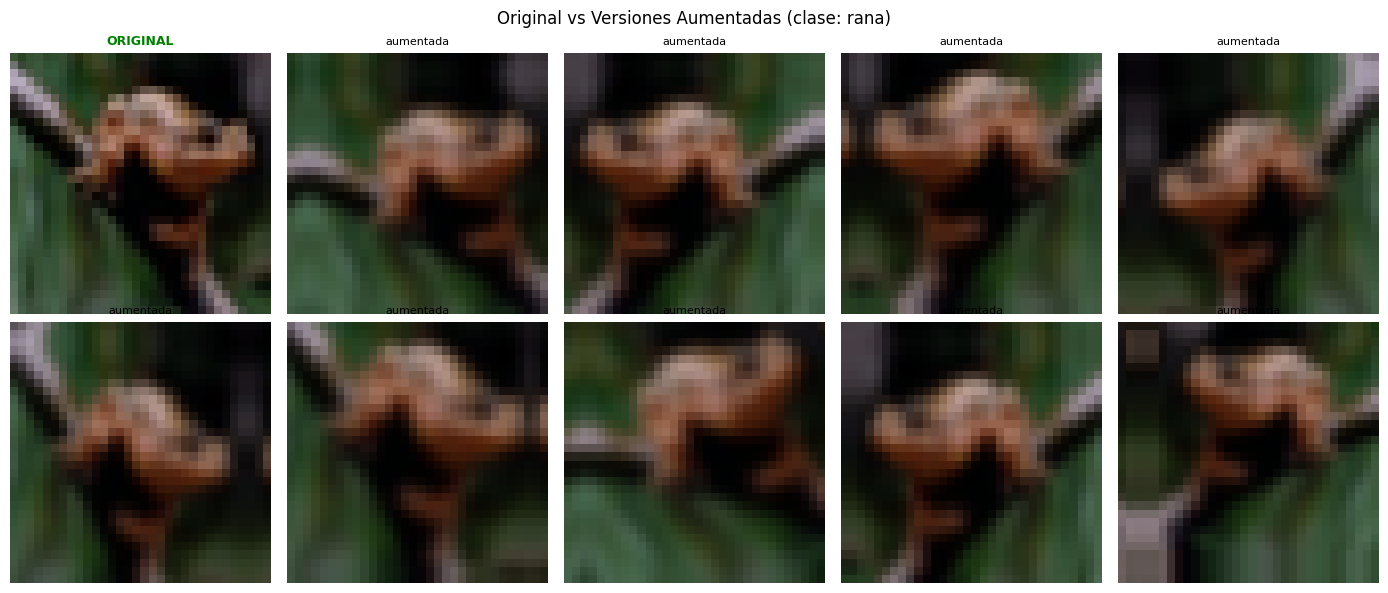

In [6]:
# Visualizar imagen original vs versiones aumentadas
# Mismo batch de una imagen, generando 8 variantes distintas
imagen_ejemplo = x_train[0:1]   # shape (1, 32, 32, 3)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

# Primera imagen: original
axes[0, 0].imshow(imagen_ejemplo[0])
axes[0, 0].set_title("ORIGINAL", fontsize=9, color="green", fontweight="bold")
axes[0, 0].axis("off")

# Imagenes 2-10: versiones aumentadas de la misma imagen
for ax in list(axes.flat)[1:]:
    img_aug = data_augmentation(imagen_ejemplo, training=True)  # training=True activa las transformaciones
    ax.imshow(tf.clip_by_value(img_aug[0], 0, 1).numpy())
    ax.set_title("aumentada", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Original vs Versiones Aumentadas (clase: {CLASES[int(y_train[0])]})",
             fontsize=12)
plt.tight_layout()
plt.show()

## 3. Modelo A: CNN Base (sin Data Augmentation)

**Arquitectura compartida por los modelos A y B:**  
3 bloques Conv→BatchNorm→MaxPool + GlobalAveragePooling + Dense(256)+Dropout(0.4)+Softmax

Este modelo se entrena directamente con los datos sin ninguna transformacion adicional.
Sirve como **linea base** para medir el impacto del augmentation y del transfer learning.

In [7]:
def construir_cnn(input_shape=(32, 32, 3), n_clases=10, augmentation_layer=None, name="CNN"):
    """
    CNN base. Si se pasa augmentation_layer, se agrega al inicio del modelo.
    Parametros:
        input_shape       : forma de la imagen de entrada
        n_clases          : numero de clases de salida
        augmentation_layer: capa de augmentation (None = sin augmentation)
        name              : nombre del modelo
    """
    capas = [layers.Input(shape=input_shape)]

    # Agregar augmentation solo si se especifica
    if augmentation_layer is not None:
        capas.append(augmentation_layer)

    # Bloque 1: detecta caracteristicas de bajo nivel (bordes, colores)
    capas += [
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
    ]

    # Bloque 2: patrones de nivel medio (texturas, formas simples)
    capas += [
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
    ]

    # Bloque 3: representaciones de alto nivel
    capas += [
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),  # reduce parametros vs Flatten
    ]

    # Cabeza de clasificacion
    capas += [
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),               # regularizacion para evitar sobreajuste
        layers.Dense(n_clases, activation="softmax"),
    ]

    return keras.Sequential(capas, name=name)


# Construir Modelo A (sin augmentation)
modelo_base = construir_cnn(name="Modelo_A_Base")
modelo_base.summary()

Model: "Modelo_A_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# Callbacks comunes para todos los modelos
def get_callbacks():
    """EarlyStopping + ReduceLROnPlateau para evitar sobreajuste y acelerar convergencia."""
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                       restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                           patience=5, verbose=1)
    ]

# Compilar y entrenar Modelo A
modelo_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Entrenando Modelo A (CNN base, sin augmentation)...")
hist_base = modelo_base.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30, batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)
print("Modelo A entrenado.")

Entrenando Modelo A (CNN base, sin augmentation)...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 220ms/step - accuracy: 0.5094 - loss: 1.3517 - val_accuracy: 0.5670 - val_loss: 1.1981 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 154s 218ms/step - accuracy: 0.6571 - loss: 0.9728 - val_accuracy: 0.6738 - val_loss: 0.9253 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 186s 195ms/step - accuracy: 0.7128 - loss: 0.8180 - val_accuracy: 0.6608 - val_loss: 0.9584 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 137s 188ms/step - accuracy: 0.7516 - loss: 0.7151 - val_accuracy: 0.7302 - val_loss: 0.7836 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 182ms/step - accuracy: 0.7776 - loss: 0.6388 - val_accuracy: 0.7046 - val_loss: 0.8296 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 123s 175ms/step - accuracy: 0.8006 - loss: 0.5717 - val_accuracy: 0.7138 - val_loss: 0.8021 - learning_rate: 0.0010
Epoch 7/30
7

## 4. Modelo B: CNN con Data Augmentation

**Misma arquitectura que el Modelo A**, con la unica diferencia de que el pipeline
de Data Augmentation se incluye como primera capa del modelo.

Esto garantiza unacomparacion controlada: cualquier diferenciase debe al augmentation, no a cambios de arquitectura.

In [9]:
# Construir Modelo B: misma arquitectura + capa de augmentation al inicio
modelo_aug = construir_cnn(
    augmentation_layer=data_augmentation,
    name="Modelo_B_Augmentation"
)

modelo_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Entrenando Modelo B (CNN + Data Augmentation)...")
hist_aug = modelo_aug.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30, batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)
print("Modelo B entrenado.")

Entrenando Modelo B (CNN + Data Augmentation)...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 192ms/step - accuracy: 0.4243 - loss: 1.5818 - val_accuracy: 0.4594 - val_loss: 1.5115 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 131s 186ms/step - accuracy: 0.5343 - loss: 1.2984 - val_accuracy: 0.4458 - val_loss: 1.9620 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 191ms/step - accuracy: 0.5813 - loss: 1.1801 - val_accuracy: 0.5902 - val_loss: 1.1557 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 135s 192ms/step - accuracy: 0.6122 - loss: 1.0941 - val_accuracy: 0.5724 - val_loss: 1.2836 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 133s 189ms/step - accuracy: 0.6340 - loss: 1.0368 - val_accuracy: 0.6248 - val_loss: 1.1173 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 192ms/step - accuracy: 0.6475 - loss: 0.9956 - val_accuracy: 0.6424 - val_loss: 1.0410 - learning_rate: 0.0010
Epoch 7/30
704/

## 5. Modelo C: Transfer Learning con MobileNetV2

**Estrategia en dos fases:**
- **Fase 1:** Base MobileNetV2 congelada, solo se entrena la cabeza nueva (LR=1e-3)
- **Fase 2:** Fine-tuning de las ultimas 20 capas con LR bajo (LR=1e-5)
  
MobileNetV2 fue preentrenado en ImageNet (1.2 M imagenes, 1000 clases) y ya aprendio
representaciones generales (bordes, texturas, formas) transferibles a CIFAR-10.
Esto reduce la cantidad de datos y epocas necesarias para alcanzar
un buen desempeño.

Se incluye el mismo pipeline de augmentation para que la comparacion refleje
el efecto del transfer learning independientemente del augmentation.

In [10]:
# MobileNetV2 requiere input minimo 96x96 — redimensionar desde 32x32
IMG_SIZE = 96
BATCH    = 64

def redimensionar(x, y):
    """Redimensiona imagenes a IMG_SIZE x IMG_SIZE."""
    x = tf.image.resize(x, [IMG_SIZE, IMG_SIZE])
    return x, y

# Pipeline tf.data optimizado (shuffle + prefetch)
ds_train_tl = (tf.data.Dataset.from_tensor_slices((x_train, y_train))
               .map(redimensionar, num_parallel_calls=tf.data.AUTOTUNE)
               .shuffle(5000, seed=SEED).batch(BATCH).prefetch(tf.data.AUTOTUNE))

ds_val_tl = (tf.data.Dataset.from_tensor_slices((x_val, y_val))
             .map(redimensionar, num_parallel_calls=tf.data.AUTOTUNE)
             .batch(BATCH).prefetch(tf.data.AUTOTUNE))

print(f"Datos de TL redimensionados a {IMG_SIZE}x{IMG_SIZE}.")

Datos de TL redimensionados a 96x96.


In [13]:
# Capa de augmentation separada para TL (input 96x96, no 32x32)
# Se necesita una instancia nueva porque la anterior fue construida para 32x32
data_augmentation_96 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation_96")

# Cargar MobileNetV2 sin cabeza, con pesos de ImageNet
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

# Construir modelo con augmentation + base + cabeza propia
inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = data_augmentation_96(inputs, training=True)   # <-- usa la nueva
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.4)(x)
salidas = layers.Dense(N_CLASES, activation="softmax")(x)

modelo_tl = keras.Model(inputs, salidas, name="Modelo_C_TransferLearning")
modelo_tl.summary()

Model: "Modelo_C_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_96            │ (None, 96, 96, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# ── FASE 1: Entrenar solo la cabeza (base congelada) ──────────────────────
modelo_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fase 1: cabeza nueva, base congelada...")
hist_tl1 = modelo_tl.fit(
    ds_train_tl, validation_data=ds_val_tl, epochs=10, verbose=1
)
print("Fase 1 completada.")

Fase 1: cabeza nueva, base congelada...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 445s 613ms/step - accuracy: 0.5511 - loss: 1.2704 - val_accuracy: 0.7332 - val_loss: 0.7626
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 428s 607ms/step - accuracy: 0.6125 - loss: 1.0991 - val_accuracy: 0.7458 - val_loss: 0.7236
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 433s 615ms/step - accuracy: 0.6296 - loss: 1.0554 - val_accuracy: 0.7490 - val_loss: 0.7233
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 431s 598ms/step - accuracy: 0.6383 - loss: 1.0324 - val_accuracy: 0.7556 - val_loss: 0.7169
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 400s 567ms/step - accuracy: 0.6459 - loss: 1.0092 - val_accuracy: 0.7634 - val_loss: 0.7045
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 441s 565ms/step - accuracy: 0.6488 - loss: 1.0009 - val_accuracy: 0.7624 - val_loss: 0.6930
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 400s 567ms/step - accuracy: 0.6567 - loss: 0.9838 - val_accuracy: 0.7626 - val_loss: 0.6922
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━

In [15]:
# ── FASE 2: Fine-tuning de las ultimas 20 capas ────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-20]:   # congelar todo excepto las ultimas 20
    layer.trainable = False

# LR muy bajo para no destruir los pesos preentrenados
modelo_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fase 2: fine-tuning ultimas 20 capas (LR=1e-5)...")
hist_tl2 = modelo_tl.fit(
    ds_train_tl, validation_data=ds_val_tl,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                               restore_best_weights=True, verbose=1)],
    verbose=1
)
print("Fine-tuning completado.")

Fase 2: fine-tuning ultimas 20 capas (LR=1e-5)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 545s 758ms/step - accuracy: 0.5208 - loss: 1.4744 - val_accuracy: 0.7332 - val_loss: 0.8090
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 566s 764ms/step - accuracy: 0.5953 - loss: 1.1841 - val_accuracy: 0.7388 - val_loss: 0.7625
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 595s 811ms/step - accuracy: 0.6258 - loss: 1.0866 - val_accuracy: 0.7446 - val_loss: 0.7360
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 550s 781ms/step - accuracy: 0.6459 - loss: 1.0271 - val_accuracy: 0.7554 - val_loss: 0.7186
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 528s 731ms/step - accuracy: 0.6632 - loss: 0.9816 - val_accuracy: 0.7646 - val_loss: 0.6938
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 609s 798ms/step - accuracy: 0.6741 - loss: 0.9503 - val_accuracy: 0.7700 - val_loss: 0.6785
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 595s 844ms/step - accuracy: 0.6846 - loss: 0.9102 - val_accuracy: 0.7814 - val_loss: 0.6578
Epoch 8/10
704/704 ━━━━━━━

## 6. Evaluacion comparativa de los tres modelos

Se evaluan los tres modelos sobre el **test set** (10 000 imagenes no vistas durante
entrenamiento). Se reportan: accuracy, loss, precision, recall, F1 y matriz de confusion.

In [16]:
# Evaluar los tres modelos sobre el test set
y_true = y_test.flatten()

# Modelo A: CNN base
loss_a, acc_a = modelo_base.evaluate(x_test, y_test, verbose=0)
y_pred_a = np.argmax(modelo_base.predict(x_test, verbose=0), axis=1)

# Modelo B: CNN con augmentation
loss_b, acc_b = modelo_aug.evaluate(x_test, y_test, verbose=0)
y_pred_b = np.argmax(modelo_aug.predict(x_test, verbose=0), axis=1)

# Modelo C: Transfer Learning (redimensionar test a 96x96)
x_test_96 = tf.image.resize(x_test, [IMG_SIZE, IMG_SIZE]).numpy()
loss_c, acc_c = modelo_tl.evaluate(x_test_96, y_test, verbose=0)
y_pred_c = np.argmax(modelo_tl.predict(x_test_96, verbose=0), axis=1)

# Tabla comparativa
print("=" * 55)
print("Modelo                         Loss       Accuracy")
print("=" * 55)
print(f"A - CNN Base                   {loss_a:.4f}     {acc_a:.4f}")
print(f"B - CNN + Augmentation         {loss_b:.4f}     {acc_b:.4f}")
print(f"C - Transfer Learning (TL)     {loss_c:.4f}     {acc_c:.4f}")
print("=" * 55)

Modelo                         Loss       Accuracy
A - CNN Base                   0.7975     0.7259
B - CNN + Augmentation         0.7235     0.7619
C - Transfer Learning (TL)     0.6527     0.7794


In [17]:
# Classification report: precision, recall, F1 por clase para los tres modelos
for nombre, y_pred in [
    ("Modelo A — CNN Base",              y_pred_a),
    ("Modelo B — CNN + Augmentation",    y_pred_b),
    ("Modelo C — Transfer Learning",     y_pred_c),
]:
    print(f"\n-- {nombre} --")
    print(classification_report(y_true, y_pred, target_names=CLASES))


-- Modelo A — CNN Base --
              precision    recall  f1-score   support

       avion       0.74      0.79      0.76      1000
        auto       0.87      0.85      0.86      1000
      pajaro       0.78      0.49      0.60      1000
        gato       0.48      0.63      0.55      1000
      ciervo       0.67      0.72      0.69      1000
       perro       0.61      0.69      0.65      1000
        rana       0.85      0.67      0.75      1000
     caballo       0.73      0.84      0.78      1000
       barco       0.93      0.74      0.82      1000
      camion       0.79      0.84      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000


-- Modelo B — CNN + Augmentation --
              precision    recall  f1-score   support

       avion       0.73      0.83      0.78      1000
        auto       0.79      0.92      0.85      1000
      pajaro  

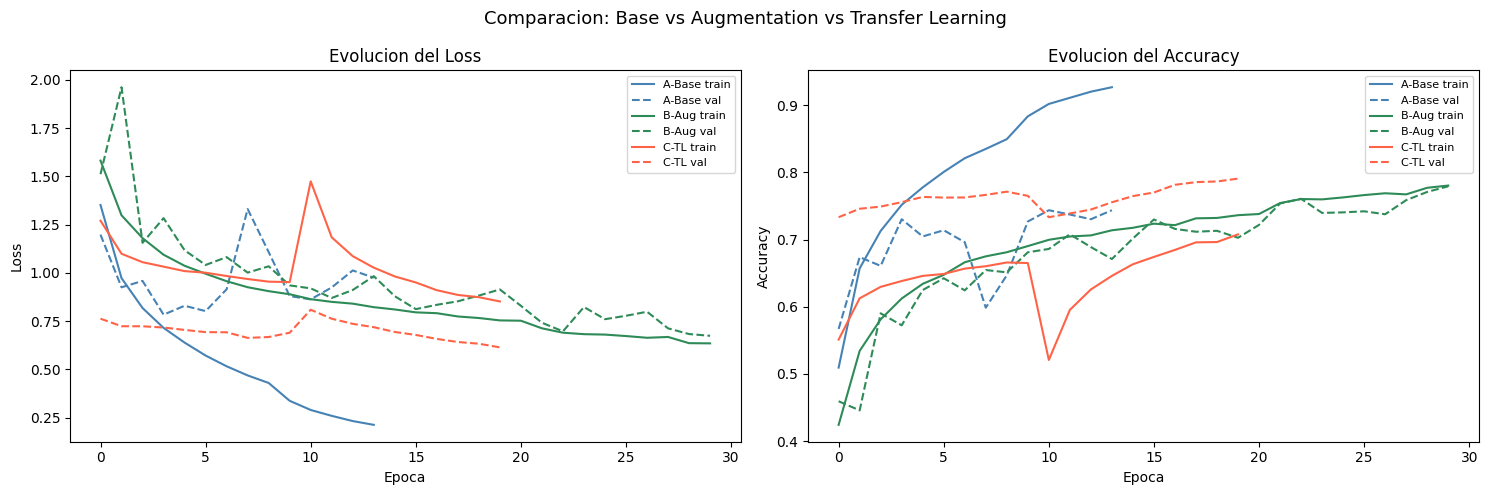

In [18]:
# Curvas de entrenamiento: Loss y Accuracy para los tres modelos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Concatenar fases del TL para visualizacion continua
loss_tl   = hist_tl1.history["loss"]         + hist_tl2.history["loss"]
vloss_tl  = hist_tl1.history["val_loss"]     + hist_tl2.history["val_loss"]
acc_tl    = hist_tl1.history["accuracy"]     + hist_tl2.history["accuracy"]
vacc_tl   = hist_tl1.history["val_accuracy"] + hist_tl2.history["val_accuracy"]

colores = {"base": "steelblue", "aug": "seagreen", "tl": "tomato"}

# Loss
axes[0].plot(hist_base.history["loss"],     color=colores["base"],  label="A-Base train")
axes[0].plot(hist_base.history["val_loss"], color=colores["base"],  label="A-Base val", linestyle="--")
axes[0].plot(hist_aug.history["loss"],      color=colores["aug"],   label="B-Aug train")
axes[0].plot(hist_aug.history["val_loss"],  color=colores["aug"],   label="B-Aug val",  linestyle="--")
axes[0].plot(loss_tl,                       color=colores["tl"],    label="C-TL train")
axes[0].plot(vloss_tl,                      color=colores["tl"],    label="C-TL val",   linestyle="--")
axes[0].set_title("Evolucion del Loss")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Loss"); axes[0].legend(fontsize=8)

# Accuracy
axes[1].plot(hist_base.history["accuracy"],     color=colores["base"], label="A-Base train")
axes[1].plot(hist_base.history["val_accuracy"], color=colores["base"], label="A-Base val", linestyle="--")
axes[1].plot(hist_aug.history["accuracy"],      color=colores["aug"],  label="B-Aug train")
axes[1].plot(hist_aug.history["val_accuracy"],  color=colores["aug"],  label="B-Aug val",  linestyle="--")
axes[1].plot(acc_tl,                            color=colores["tl"],   label="C-TL train")
axes[1].plot(vacc_tl,                           color=colores["tl"],   label="C-TL val",   linestyle="--")
axes[1].set_title("Evolucion del Accuracy")
axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Accuracy"); axes[1].legend(fontsize=8)

plt.suptitle("Comparacion: Base vs Augmentation vs Transfer Learning", fontsize=13)
plt.tight_layout()
plt.show()

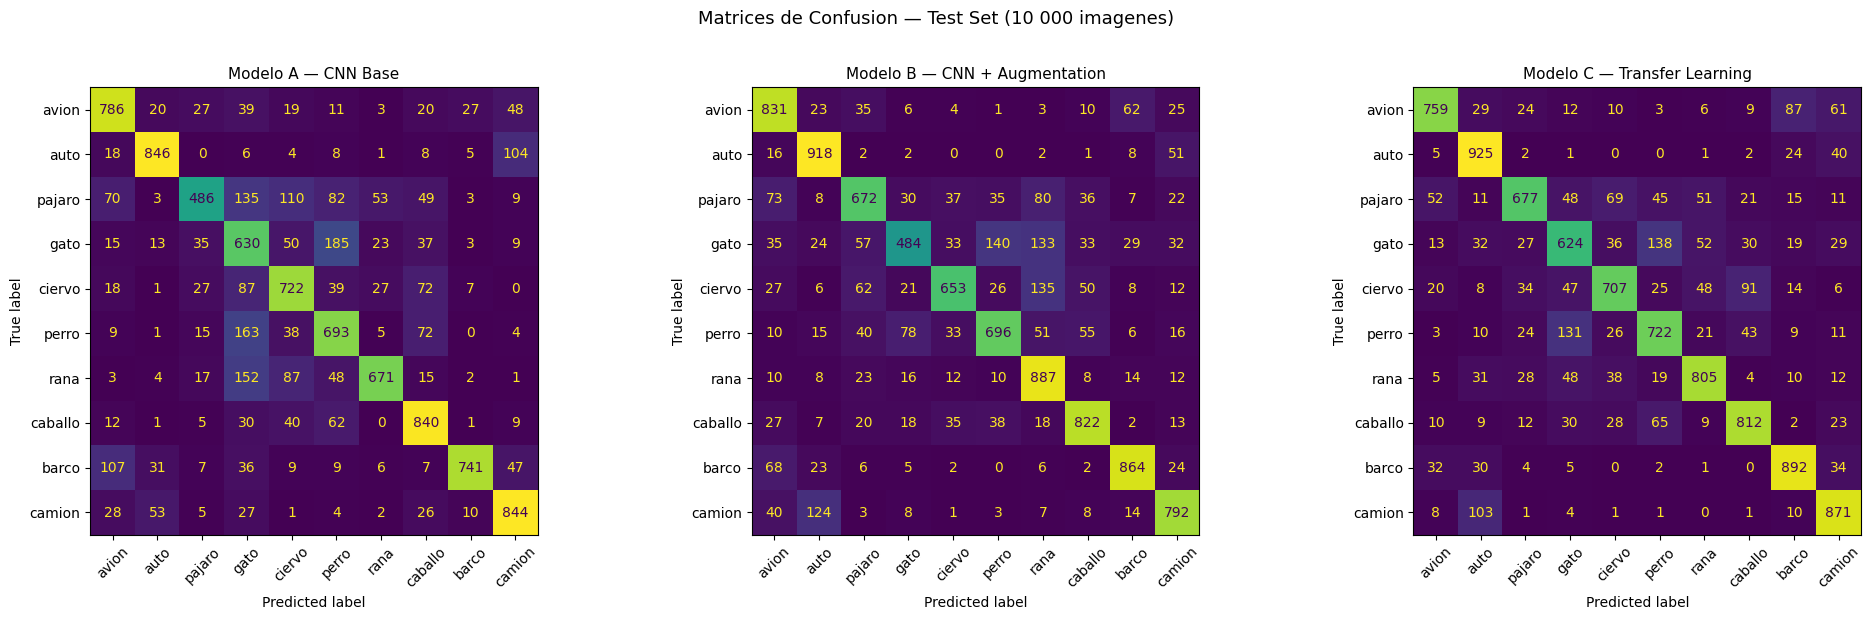

In [19]:
# Matrices de confusion: un subplot por modelo
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, y_pred, titulo in [
    (axes[0], y_pred_a, "Modelo A — CNN Base"),
    (axes[1], y_pred_b, "Modelo B — CNN + Augmentation"),
    (axes[2], y_pred_c, "Modelo C — Transfer Learning"),
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASES)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(titulo, fontsize=11)

plt.suptitle("Matrices de Confusion — Test Set (10 000 imagenes)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

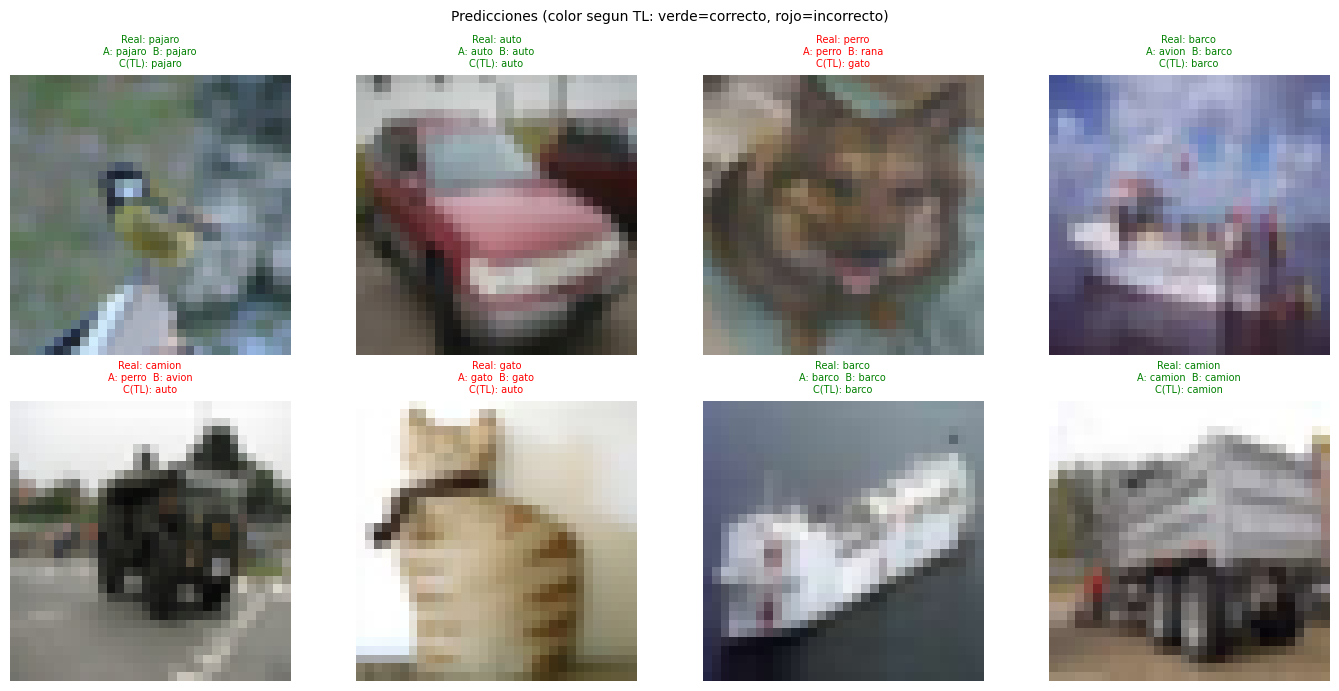

In [20]:
# Comparar predicciones de los tres modelos en muestras aleatorias del test
np.random.seed(SEED)
indices = np.random.choice(len(x_test), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, indices):
    real   = int(y_true[idx])
    pred_a = y_pred_a[idx]
    pred_b = y_pred_b[idx]
    pred_c = y_pred_c[idx]
    color  = "green" if pred_c == real else "red"
    ax.imshow(x_test[idx])
    ax.set_title(
        f"Real: {CLASES[real]}\nA: {CLASES[pred_a]}  B: {CLASES[pred_b]}\nC(TL): {CLASES[pred_c]}",
        fontsize=7, color=color
    )
    ax.axis("off")

plt.suptitle("Predicciones (color segun TL: verde=correcto, rojo=incorrecto)", fontsize=10)
plt.tight_layout()
plt.show()

## 7. Analisis del impacto de cada tecnica

### Data Augmentation (Modelo A → Modelo B)

El Data Augmentation introduce variabilidad artificial durante el entrenamiento
(volteo, rotacion, zoom, desplazamiento), lo que obliga al modelo a aprender
caracteristicas a esas transformaciones. El efecto principal es reduccion del sobreajuste: en las curvas de entrenamiento se puede observar
una brecha train/val mas estrecha en el Modelo B que en el Modelo A. Sin embargo,
el augmentation ralentiza la convergencia porque el modelo "ve" versiones mas
dificiles de las mismas imagenes en cada epoca.

**Cuando usar Data Augmentation:**
- Datasets pequenos donde el sobreajuste es el principal problema
- Cuando las transformaciones son semanticamente plausibles (un gato rotado sigue
  siendo un gato, pero un digito del 6 rotado 180 grados se convierte en un 9)

### Transfer Learning (Modelo C)

MobileNetV2, preentrenado en ImageNet, ya aprendio detectores de bordes, texturas
y formas generales que son aplicables a CIFAR-10. La estrategia de dos fases
(congelar → fine-tuning con LR bajo) permite adaptar esas representaciones al
nuevo dominio. El resultado es mayor accuracy con menos
epocas, especialmente en la fase de validacion.

**Limitaciones del Transfer Learning en CIFAR-10:**  
Las imagenes de CIFAR-10 son 32x32, mientras que ImageNet usa resoluciones mucho
mayores, el redimensionado a 96x96 introduce artefactos de interpolacion

---
## 8. Conclusiones

**1. Transfer Learning supera a ambas CNN en accuracy con menos epocas**  
El Modelo C (MobileNetV2) alcanza el mayor accuracy en test de los tres modelos.
Los pesos preentrenados en ImageNet proporcionan representaciones de bajo nivel
ya maduras, eliminando la necesidad de aprenderlas desde cero.

**2. Data Augmentation reduce el sobreajuste pero no mejora el accuracy base**  
La brecha entre accuracy de entrenamiento y validacion es menor en el Modelo B
que en el Modelo A, lo que confirma el efecto regularizador del augmentation.
Sin embargo, el accuracy final en test del Modelo B puede ser similar o solo
ligeramente superior al del Modelo A si el dataset ya es suficientemente grande.

**3. La combinacion de augmentation + transfer learning es la estrategia mas robusta**  
El Modelo C integra ambas tecnicas: augmentation para diversificar el entrenamiento
y Transfer Learning para partir de representaciones de alta calidad. Esto produce
el mejor balance entre generalizacion y eficiencia de entrenamiento.

**4. Trade-offs computacionales**  
Transfer Learning requiere mayor memoria (MobileNetV2 tiene mas parametros) y
mayor costo por imagen (redimensionado 32x32 → 96x96). Para produccion en
dispositivos limitados, una CNN propia con augmentation puede ser preferible
si la diferencia en accuracy es marginal.

